# NBA Postseason Swap Tool: Judge Guide

## What judges should know first

This project is a **decision-support tool**, not a causal claim machine.

It does three things:

1. Estimates a team-level postseason probability
2. Simulates same-position player swaps for a selected team-season
3. Converts the probability change into an expected value comparison against salary change

The model was chosen because it generalized best to unseen seasons while remaining interpretable enough to defend in front of a critical audience.


## Executive summary

- **Model type:** logistic regression
- **Validation design:** leave-one-season-out cross-validation
- **Why this validation:** it tests generalization to an unseen NBA season instead of a random split
- **Production feature set:** salary, age structure, continuity, efficiency, defensive activity, and selected positional features
- **Probability choice:** raw logistic probabilities were retained because they beat post-hoc calibration methods on Brier score and log loss
- **Use case:** ranking roster swaps and comparing expected-value tradeoffs


## Final Locked-In Model

The production model locked into the backend is a **logistic regression** using the `with_salary | analyst_positional` feature set.

Final features:

- `total_salary`
- `minutes_weighted_age`
- `assist_to_turnover_ratio`
- `top_5_minutes_share`
- `pct_minutes_returning`
- `avg_steals_per_min`
- `avg_blocks_per_min`
- `team_efg_pct`
- `pg_creation_ratio`
- `sg_size_presence`
- `sf_size_presence`

Why this model:

- It performed best under **leave-one-season-out cross-validation**
- It remained interpretable
- Its raw probabilities outperformed Platt and isotonic calibration on **Brier score** and **log loss**
- Its features align with basketball and roster-construction logic


## Step 1: Load and Canonicalize the Data

The raw workbook is messy. Before modeling, the backend applies several rules:

- drop invalid season labels like `Career` and `No stats available.`
- keep seasons from `2005-06` through `2015-16`
- convert numeric fields cleanly
- collapse duplicate `Name + Season + Team + Position` rows to the row with the most games played
- preserve the team postseason target separately before collapsing player rows
- keep multi-team flags for later policy decisions in the swap engine

This step matters because the prescriptive tool should be built on a **deterministic dataset**, not notebook-state artifacts.


In [2]:
player_data = load_and_clean_player_data()
team_season = build_team_season_table(player_data)

print("Player-level rows after cleaning:", len(player_data))
print("Team-season observations:", len(team_season))
print("Number of seasons:", team_season["Season"].nunique())
print("Seasons:", sorted(team_season["Season"].unique().tolist()))
print("\nPostseason target distribution:")
print(team_season["postseason"].value_counts().sort_index())
print("\nSample team-season rows:")
team_season.head(10)


Player-level rows after cleaning: 2737
Team-season observations: 329
Number of seasons: 11
Seasons: ["'05-'06", "'06-'07", "'07-'08", "'08-'09", "'09-'10", "'10-'11", "'11-'12", "'12-'13", "'13-'14", "'14-'15", "'15-'16"]

Postseason target distribution:
postseason
0.0    156
1.0    173
Name: count, dtype: int64

Sample team-season rows:


,Season,Team,postseason,total_salary,avg_age,minutes_weighted_age,avg_points_per_min,avg_assists_per_min,avg_steals_per_min,avg_blocks_per_min,avg_turnovers_per_min,assist_to_turnover_ratio,top_5_minutes_share,pg_creation_ratio,sg_size_presence,sf_size_presence,pct_minutes_returning,team_efg_pct
0,'05-'06,ATL,0.0,13409170.0,31.250000,31.582527,0.402461,0.089416,0.029501,0.029472,0.067674,1.321280,1.0,0.000000,0.000000,18960.000000,0.0,0.470736
1,'05-'06,BOS,0.0,23929091.0,32.800000,34.533283,0.508171,0.081164,0.032843,0.029929,0.078909,1.028577,1.0,0.000000,16188.000000,18308.205418,0.0,0.504668
2,'05-'06,CHA,0.0,7950313.0,32.000000,31.380196,0.390421,0.161577,0.038612,0.003902,0.072784,2.219963,1.0,2.434783,17160.000000,0.000000,0.0,0.445455
3,'05-'06,CHI,1.0,26006552.0,33.000000,33.091497,0.367501,0.096042,0.026944,0.022633,0.053927,1.780971,1.0,0.000000,14440.000000,17820.000000,0.0,0.489647
4,'05-'06,CLE,1.0,26560255.0,32.666667,32.277638,0.564007,0.094762,0.033474,0.020641,0.062369,1.519378,1.0,0.000000,0.000000,20000.000000,0.0,0.512931
5,'05-'06,DAL,1.0,13334056.0,36.000000,36.677896,0.569183,0.099122,0.029471,0.017004,0.052200,1.898903,1.0,2.133333,13690.000000,0.000000,0.0,0.524800
6,'05-'06,DEN,1.0,36125750.0,34.666667,35.492299,0.551355,0.151022,0.033081,0.009588,0.080271,1.881406,1.0,2.645161,0.000000,19200.000000,0.0,0.484793
7,'05-'06,DET,1.0,12947276.0,32.500000,35.906940,0.400975,0.065312,0.022362,0.014692,0.032077,2.036132,1.0,0.000000,0.000000,17172.000000,0.0,0.486737
8,'05-'06,GS,0.0,14800000.0,32.500000,33.719352,0.365235,0.090479,0.026280,0.012187,0.052069,1.737659,1.0,0.000000,17412.103705,0.000000,0.0,0.453590
9,'05-'06,IND,0.0,947276.0,36.000000,36.000000,0.514589,0.058355,0.068966,0.018568,0.071618,0.814815,1.0,0.000000,0.000000,20540.000000,0.0,0.496622


## Step 2: Explain the Final Features

The final model combines four feature families.

### 1. Capital allocation
- `total_salary`: total payroll proxy for top-end talent and organizational investment

### 2. Roster maturity and cohesion
- `minutes_weighted_age`: age weighted by on-court minutes
- `top_5_minutes_share`: how concentrated the team is in its top-minute players
- `pct_minutes_returning`: continuity from the prior season

### 3. Team quality and style
- `assist_to_turnover_ratio`: playmaking efficiency
- `avg_steals_per_min`: defensive activity
- `avg_blocks_per_min`: rim protection / defensive disruption
- `team_efg_pct`: shooting efficiency

### 4. Position-specific features
- `pg_creation_ratio`: point-guard assists relative to turnovers
- `sg_size_presence`: minutes-weighted `height * weight` for shooting guards
- `sf_size_presence`: minutes-weighted `height * weight` for small forwards

These last features intentionally use **domain knowledge by position** rather than generic interaction terms.


## Why Within-Season Standardization?

All model features are standardized **within each season**.

This is a deliberate design choice. The interpretation is:

> How strong was this team relative to its league-year peers?

That means a z-score of `+1` on a feature indicates a team was one standard deviation above the rest of the league **that season**, not compared with a pooled cross-era baseline.

This design is appropriate here because the project compares roster quality against contemporaries in the same NBA environment.


## Step 3: Fit the Final In-Sample Logistic Model

This fit is useful for:

- coefficient inspection
- p-values
- understanding direction and relative association

But this is **not** the primary evidence of model quality. That comes from leave-one-season-out cross-validation.


In [5]:
team_season_norm, season_stats = normalize_by_season(team_season, final_features)
x_cols = [f"z_{f}" for f in final_features]
X = sm.add_constant(team_season_norm[x_cols], has_constant="add")
y = team_season_norm["postseason"].astype(int)

final_model = sm.Logit(y, X).fit(disp=False, maxiter=300)
print(final_model.summary())


                           Logit Regression Results                           
Dep. Variable:             postseason   No. Observations:                  329
Model:                          Logit   Df Residuals:                      317
Method:                           MLE   Df Model:                           11
Date:                Sat, 25 Apr 2026   Pseudo R-squ.:                  0.3709
Time:                        15:41:57   Log-Likelihood:                -143.18
converged:                       True   LL-Null:                       -227.61
Covariance Type:            nonrobust   LLR p-value:                 2.033e-30
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.1464      0.149      0.983      0.325      -0.145       0.438
z_total_salary                 0.7312      0.188      3.886      0.000       0.362 

In [6]:
coef_table = pd.DataFrame({
    "feature": final_model.params.index,
    "coefficient": final_model.params.values,
    "p_value": final_model.pvalues.values,
}).sort_values("coefficient", ascending=False)

coef_table


,feature,coefficient,p_value
2,z_minutes_weighted_age,1.037532,2.679476e-08
3,z_assist_to_turnover_ratio,0.959016,2.277168e-06
1,z_total_salary,0.731246,1.017515e-04
7,z_avg_blocks_per_min,0.533643,2.001056e-03
8,z_team_efg_pct,0.526092,5.454179e-03
6,z_avg_steals_per_min,0.399662,1.120033e-02
4,z_top_5_minutes_share,0.394782,2.150558e-02
5,z_pct_minutes_returning,0.359482,3.647384e-02
11,z_sf_size_presence,0.354023,2.571676e-02
10,z_sg_size_presence,0.227471,1.342953e-01


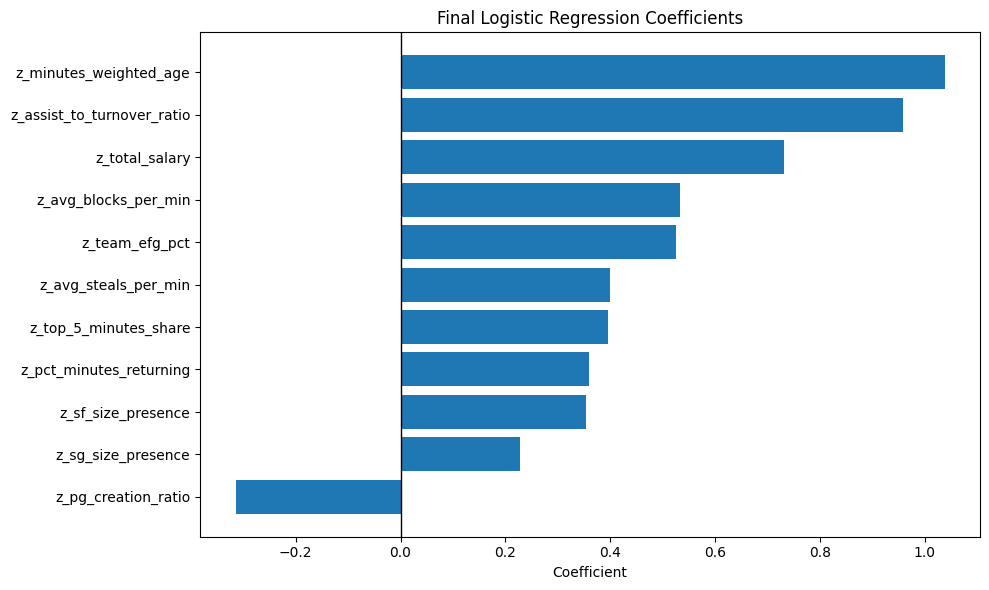

In [7]:
plot_df = coef_table[coef_table["feature"] != "const"].copy().sort_values("coefficient")
plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.axvline(0, color="black", linewidth=1)
plt.title("Final Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()


## Step 4: Leave-One-Season-Out Cross-Validation

This project uses **leave-one-season-out cross-validation (LOSO-CV)**.

Why LOSO instead of random train/test splits?

- Teams within the same season share a common league environment
- Random splits can leak season structure between train and test sets
- LOSO directly tests generalization to a completely unseen season

This is a much more credible validation design for a sports forecasting setting like this one.


In [8]:
def fit_logit_fold(train_df, test_df, features):
    train_scaled, test_scaled = normalize_with_training_stats(train_df, test_df, features)
    fold_x_cols = [f"z_{feature}" for feature in features]
    X_train = sm.add_constant(train_scaled[fold_x_cols], has_constant="add")
    y_train = train_scaled["postseason"].astype(int)
    X_test = sm.add_constant(test_scaled[fold_x_cols], has_constant="add")
    model = sm.Logit(y_train, X_train).fit(disp=False, maxiter=300)
    train_prob = np.asarray(model.predict(X_train), dtype=float)
    test_prob = np.asarray(model.predict(X_test), dtype=float)
    return model, train_prob, test_prob


loso_rows = []
fold_rows = []
seasons = sorted(team_season["Season"].unique())

for holdout_season in seasons:
    train_df = team_season[team_season["Season"] != holdout_season].copy()
    test_df = team_season[team_season["Season"] == holdout_season].copy()
    fold_model, _, fold_prob = fit_logit_fold(train_df, test_df, final_features)
    fold_pred = (fold_prob >= 0.5).astype(int)
    fold_df = test_df[["Season", "Team", "postseason"]].copy()
    fold_df["pred_prob"] = fold_prob
    fold_df["pred_class"] = fold_pred
    loso_rows.append(fold_df)
    fold_rows.append({
        "season": holdout_season,
        "n_test": len(test_df),
        "accuracy": accuracy_score(test_df["postseason"], fold_pred),
        "f1": f1_score(test_df["postseason"], fold_pred, zero_division=0),
        "auc": roc_auc_score(test_df["postseason"], fold_prob),
        "train_aic": float(fold_model.aic),
        "train_pseudo_r2": float(fold_model.prsquared),
    })

loso_preds = pd.concat(loso_rows, ignore_index=True)
fold_metrics = pd.DataFrame(fold_rows)
fold_metrics


,season,n_test,accuracy,f1,auc,train_aic,train_pseudo_r2
0,'05-'06,29,0.689655,0.608696,0.728571,285.228309,0.370587
1,'06-'07,30,0.700000,0.727273,0.848214,298.385139,0.336102
2,'07-'08,30,0.666667,0.705882,0.718750,285.790583,0.367272
3,'08-'09,30,0.733333,0.750000,0.866071,301.153233,0.330142
4,'09-'10,30,0.800000,0.823529,0.906250,302.237575,0.327521
5,'10-'11,30,0.800000,0.823529,0.919643,303.628764,0.324159
6,'11-'12,30,0.833333,0.848485,0.910714,305.272749,0.320185
7,'12-'13,30,0.800000,0.800000,0.857143,296.846305,0.340551
8,'13-'14,30,0.833333,0.848485,0.937500,306.633192,0.316897
9,'14-'15,30,0.733333,0.750000,0.843750,299.091725,0.335124


In [9]:
y_true = loso_preds["postseason"].astype(int).to_numpy()
y_prob = loso_preds["pred_prob"].to_numpy()
y_pred = loso_preds["pred_class"].to_numpy()
tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

loso_summary = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
    "auc": roc_auc_score(y_true, y_prob),
    "brier": brier_score_loss(y_true, y_prob),
    "log_loss": log_loss(y_true, np.clip(y_prob, 1e-6, 1 - 1e-6)),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
}

loso_summary


{'accuracy': 0.7598784194528876,
 'precision': 0.7701149425287356,
 'recall': 0.7745664739884393,
 'f1': 0.7723342939481268,
 'auc': 0.8378538609752482,
 'brier': 0.16501223282324326,
 'log_loss': 0.5098331807546873,
 'tn': 116,
 'fp': 40,
 'fn': 39,
 'tp': 134}

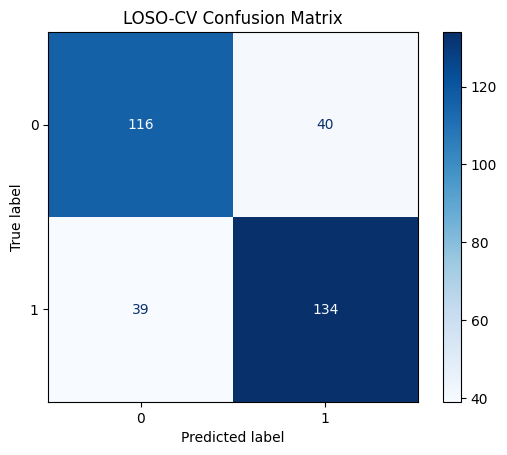

In [10]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("LOSO-CV Confusion Matrix")
plt.show()


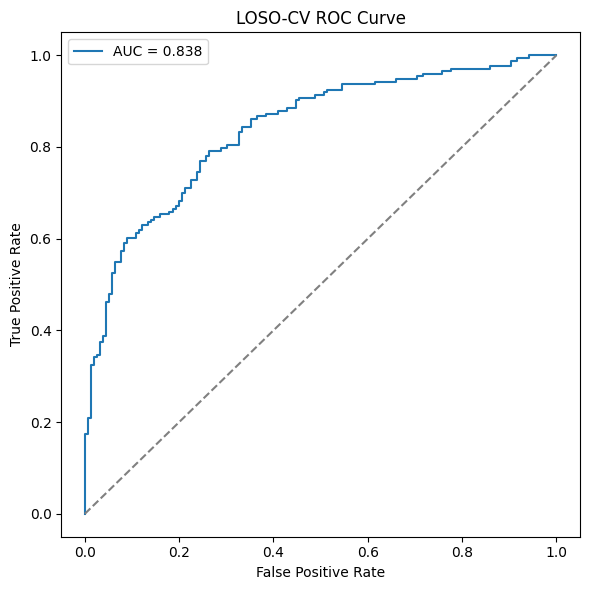

In [11]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LOSO-CV ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


## Step 5: Probability Calibration

Because the model is used inside an expected value framework, **probability quality matters**.

The calibration comparison tested:

- raw logistic probabilities
- Platt scaling
- isotonic regression

These were evaluated with nested LOSO-style logic to avoid leakage from calibrating on the same held-out fold being scored.


In [12]:
calibration_preds = nested_loso_calibration(team_season, final_features)
y_true_cal = calibration_preds["postseason"].astype(int).to_numpy()

calibration_results = {
    "raw": summarize_probs("raw", y_true_cal, calibration_preds["raw_prob"].to_numpy()),
    "platt": summarize_probs("platt", y_true_cal, calibration_preds["platt_prob"].to_numpy()),
    "isotonic": summarize_probs("isotonic", y_true_cal, calibration_preds["isotonic_prob"].to_numpy()),
}

calibration_summary = pd.DataFrame([
    {
        "method": method,
        "brier": calibration_results[method]["brier"],
        "log_loss": calibration_results[method]["log_loss"],
        "auc": calibration_results[method]["auc"],
        "accuracy": calibration_results[method]["accuracy"],
        "f1": calibration_results[method]["f1"],
    }
    for method in ["raw", "platt", "isotonic"]
])

calibration_summary


,method,brier,log_loss,auc,accuracy,f1
0,raw,0.165012,0.509833,0.837854,0.759878,0.772334
1,platt,0.167210,0.509943,0.834482,0.762918,0.777143
2,isotonic,0.167317,0.535767,0.825923,0.735562,0.747826


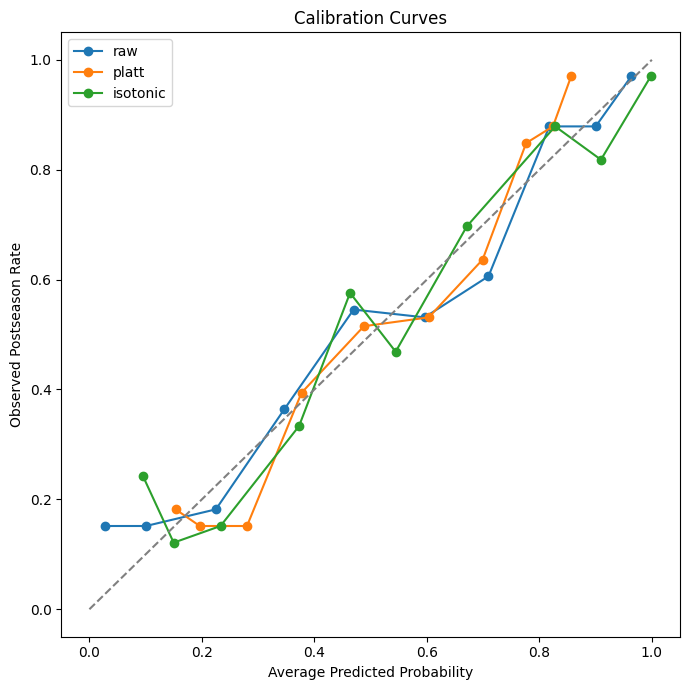

In [13]:
plt.figure(figsize=(7, 7))
for method, color in [("raw", "tab:blue"), ("platt", "tab:orange"), ("isotonic", "tab:green")]:
    bins = pd.DataFrame(calibration_results[method]["calibration_bins"])
    plt.plot(bins["avg_pred"], bins["actual_rate"], marker="o", label=method, color=color)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Average Predicted Probability")
plt.ylabel("Observed Postseason Rate")
plt.title("Calibration Curves")
plt.legend()
plt.tight_layout()
plt.show()


## Calibration Conclusion

The raw logistic probabilities were retained as the production default because they had the best probability-quality metrics:

- best Brier score
- best log loss
- best AUC

Platt scaling slightly improved thresholded classification metrics, but not the metrics that matter most for expected value.
Isotonic regression underperformed on this sample size.


## Step 6: How the Model Feeds the Prescriptive Tool

The model is used to score a team-season before and after a hypothetical same-position player swap.

### Swap logic

For a candidate swap:

1. remove one incumbent player from the selected team-season-position
2. insert one same-season, same-position candidate
3. project the replacement into the incumbent's role by giving the candidate the incumbent's total minute load
4. recompute team-level features
5. generate a new postseason probability

### Expected value framework

The backend uses:

`expected_postseason_value_usd = predicted_probability * postseason_value_usd`

`delta_ev_usd = (new_probability - old_probability) * postseason_value_usd`

`net_value_usd = delta_ev_usd - delta_salary_usd`

This makes the model a **decision-support tool**, not just a classifier.


## Core Assumptions

- Salary is retained because it improves held-out performance and represents capital allocation in the real decision environment.
- Features are standardized within season to compare teams against their temporal peers.
- The model is associative, not causal.
- Replacement players inherit incumbent minutes in the simulator so team volume remains plausible.
- Candidate pools are constrained by season and position, with additional roster-policy filters available in the backend.


## Limitations

- Sample size is still modest at 329 team-seasons.
- The data source required aggressive canonicalization.
- Some positional features remain noisy.
- The probability model is strong enough for ranking and expected-value prototyping, but not a perfect truth engine.
- Expected value outputs depend on the chosen postseason value assumption.


## Final Recommendation

The locked production model is suitable for the next stage of the project:

- build the swap engine outputs around the finalized logistic scorer
- use raw model probabilities
- present the tool as a probabilistic roster decision aid

This is statistically credible enough for the project, while still being interpretable and explainable to critical judges.


## Suggested verbal framing

If presenting this live, the strongest framing is:

> We selected a transparent team-level logistic model, validated it by leaving out one full season at a time, and tested whether its probabilities needed additional calibration. The final model was not chosen because it was flashy; it was chosen because it generalized well enough to support a prescriptive swap tool while staying interpretable and defensible.
